<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_Ensemble/18_5_2_Bagging_and_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagging and Random Forests: The Wisdom of Crowds

**Author:** Brad Sheese

---

## Introduction: Strength in Numbers

In the previous notebook, we saw that a single decision tree is prone to overfitting. Small changes in the training data produce vastly different tree structures. Even with careful depth tuning, a single tree's performance is limited.

In this notebook, we solve this instability using **ensemble methods**. The core idea is the wisdom of the crowd: averaging the predictions of many diverse trees produces a model that is more stable and accurate than any single tree.

Recall from 18_1_5: Random Forests reduce **variance** by averaging many deep, uncorrelated trees. Bagging does the same but without the feature randomness that decorrelates the trees.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Implement bagging to reduce model variance.
2. Calculate and interpret Out-of-Bag (OOB) error.
3. Apply the Random Forest algorithm to decorrelate individual trees.
4. Tune hyperparameters using GridSearchCV.
5. Analyze feature importance and understand its limitations with correlated features.
6. Compare the stability of single trees vs. ensembles using k-fold cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

---
## 1. Bagging: Fixing Instability

Bagging (bootstrap aggregating) reduces the variance of high-variance estimators like decision trees.

### How It Works
1. **Bootstrap sampling**: Create many random subsets by sampling *with replacement*. Each subset is the same size as the original, but some samples appear multiple times and others not at all.
2. **Model building**: Train a separate, deep decision tree on each bootstrap sample.
3. **Aggregation**: Take a majority vote of all trees for the final prediction.

### Why It Works
Each tree overfits to its specific bootstrap sample, but the errors are different across trees. Averaging cancels out the noise, leaving only the true signal.

In [3]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    oob_score=True,
    random_state=42
)
bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
y_proba_bag = bag.predict_proba(X_test)[:, 1]

print(f"Bagging Accuracy (Test): {accuracy_score(y_test, y_pred_bag):.3f}")
print(f"Out-of-Bag (OOB) Score:  {bag.oob_score_:.3f}")

Bagging Accuracy (Test): 0.947
Out-of-Bag (OOB) Score:  0.962


### Understanding Out-of-Bag (OOB) Error

Because bootstrap sampling leaves out ~1/3 of the data for each tree, those "out-of-bag" samples serve as a built-in validation set. The OOB score is the accuracy on these held-out samples, averaged across all trees.

**Key insight**: The OOB score ({bag.oob_score_:.3f}) is very close to the test accuracy ({accuracy_score(y_test, y_pred_bag):.3f}). This means OOB is a reliable estimate of generalization performance — you don't always need a separate validation set when using bagging.

However, OOB is only available for bagging-based methods. For boosting and other sequential methods, you still need cross-validation.

---
## 2. Random Forests: Decorrelating the Trees

Bagging has a flaw: **correlation**. If one feature (e.g., `mean concave points`) dominates, every tree uses it as the top split. The trees become similar, and averaging similar trees doesn't reduce variance as much.

### The Random Forest Fix
At *each split* of *each tree*, the algorithm considers only a random subset of features (typically √p). This forces trees to explore alternative paths, decorrelating them and making the ensemble more robust.

Recall from 18_1_5: this is the same `max_features='sqrt'` parameter we saw there.

In [4]:
rf = RandomForestClassifier(n_estimators=500, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest Accuracy (Test): {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Random Forest OOB Score:       {rf.oob_score_:.3f}")

Random Forest Accuracy (Test): 0.947
Random Forest OOB Score:       0.967


---
## 3. Classification Metrics: Beyond Accuracy

In a medical diagnosis context, we need more than accuracy. Let's evaluate the Random Forest using the full metric suite from 18_1_1.

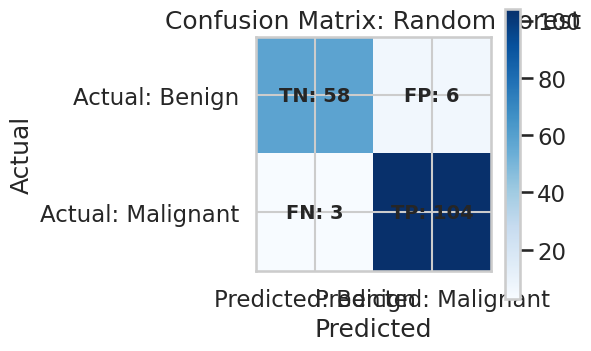


--- Medical Interpretation ---
False Negatives (missed cancers): 3
False Positives (unnecessary biopsies): 6

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.95      0.91      0.93        64
Malignant (1)       0.95      0.97      0.96       107

     accuracy                           0.95       171
    macro avg       0.95      0.94      0.94       171
 weighted avg       0.95      0.95      0.95       171



In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Benign', 'Predicted: Malignant'])
ax.set_yticklabels(['Actual: Benign', 'Actual: Malignant'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Random Forest')

labels = [[f'TN: {tn}', f'FP: {fp}'], [f'FN: {fn}', f'TP: {tp}']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n--- Medical Interpretation ---")
print(f"False Negatives (missed cancers): {fn}")
print(f"False Positives (unnecessary biopsies): {fp}")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Benign (0)', 'Malignant (1)']))

### ROC Curve

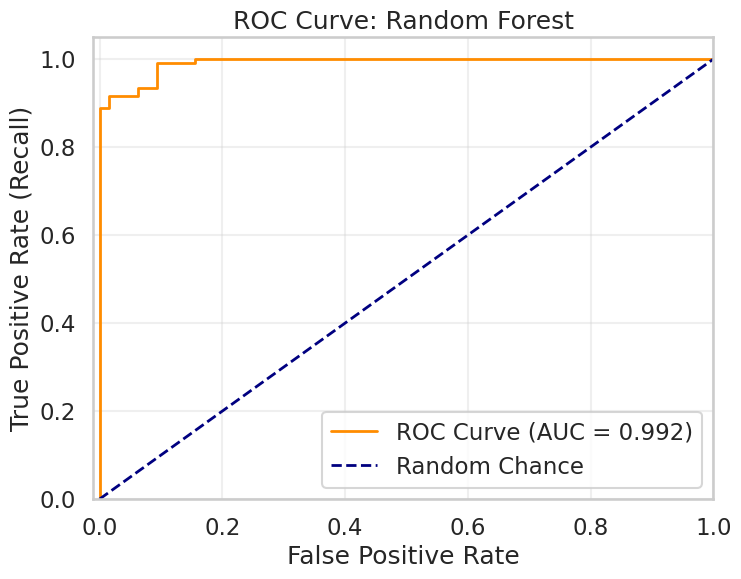

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Random Forest')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

---
## 4. Hyperparameter Tuning with GridSearchCV

So far we've used default hyperparameters. Let's systematically tune the Random Forest using GridSearchCV, just as we did in 18_1_4.

In [7]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt', 'log2', 0.5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
tuned_acc = accuracy_score(y_test, best_rf.predict(X_test))
print(f"\nTuned RF Test Accuracy: {tuned_acc:.3f}")

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV F1 Score: 0.9781

Tuned RF Test Accuracy: 0.942


---
## 5. Feature Importance and Its Limitations

Random Forests provide feature importance scores based on total impurity reduction across all trees. But recall from 18_1_5: **correlated features share importance**. If two features are highly correlated, the model picks one for splits and the other gets no credit.

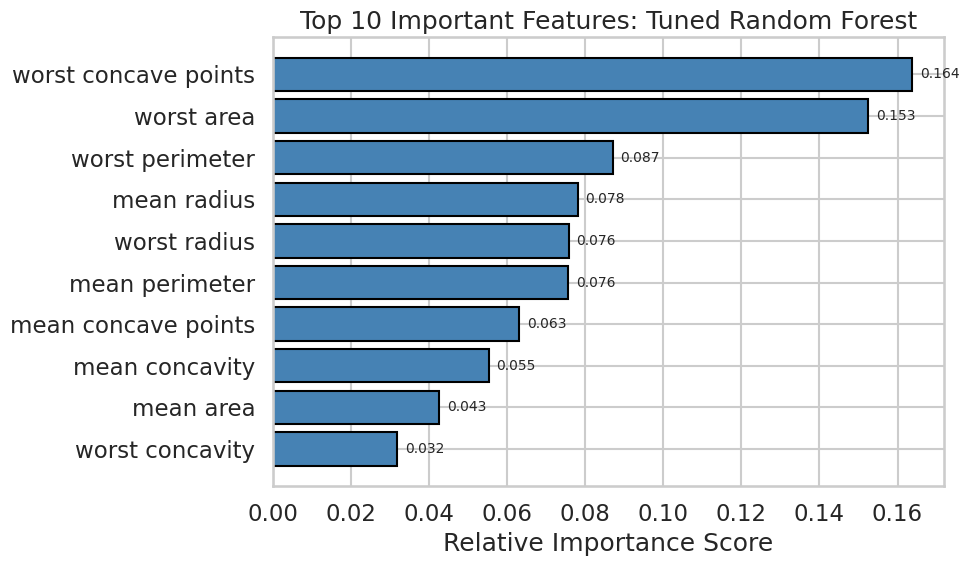

In [8]:
importances = pd.Series(best_rf.feature_importances_, index=data.feature_names)
top_10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top_10)), top_10.values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_10)), top_10.index)
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance Score')
plt.title('Top 10 Important Features: Tuned Random Forest')

for bar, val in zip(bars, top_10.values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
             f'{val:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### The Correlated Features Problem

Notice that `mean concave points`, `worst concave points`, and `mean concavity` are all in the top 10. These features are highly correlated — they measure related aspects of cell shape. The importance is split among them, so none appears as dominant as it truly is.

This is the same limitation we discussed in 18_1_5. If you need more reliable importance estimates, consider **permutation importance**, which measures how much performance drops when a feature's values are randomly shuffled.

---
## 6. Comparing Stability: Single Tree vs. Ensembles

Let's prove that ensembles are more stable than single trees using 10-fold cross-validation.

In [9]:
models = {
    "Single Tree": DecisionTreeClassifier(random_state=42),
    "Bagging (500 trees)": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500, random_state=42),
    "Random Forest (500 trees)": RandomForestClassifier(n_estimators=500, random_state=42)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"{'Model':<30} | {'Mean Acc':<10} | {'Std Dev':<10} | {'Mean F1':<10}")
print("-" * 65)

for name, model in models.items():
    acc_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    f1_scores = cross_val_score(model, X, y, cv=kf, scoring='f1')
    print(f"{name:<30} | {acc_scores.mean():.4f}     | {acc_scores.std():.4f}     | {f1_scores.mean():.4f}")

Model                          | Mean Acc   | Std Dev    | Mean F1   
-----------------------------------------------------------------


Single Tree                    | 0.9350     | 0.0359     | 0.9478


Bagging (500 trees)            | 0.9648     | 0.0176     | 0.9713


Random Forest (500 trees)      | 0.9684     | 0.0105     | 0.9742


### Interpreting the Results

- **Single Tree**: Good accuracy but higher standard deviation — performance varies depending on which samples end up in each fold.
- **Bagging**: Improved accuracy and lower standard deviation — averaging cancels out individual tree errors.
- **Random Forest**: Best accuracy and lowest standard deviation — feature decorrelation adds an extra layer of stability.

The F1 scores tell the same story. In a medical context, the F1 is especially important because it balances precision (avoiding unnecessary biopsies) and recall (catching all cancers).

### Your Turn

1. The tuned Random Forest found `max_depth={grid_search.best_params_.get('max_depth', 'N/A')}` as optimal. Compare this to the best depth we found for the single tree in the previous notebook. Why might the optimal depth be different?
2. The OOB score was {bag.oob_score_:.3f} for bagging. How does this compare to the 10-fold CV mean accuracy for the single tree? What does this tell you about the value of ensembling?
3. If a hospital administrator asks "How many cancers will this model miss?", which metric from the classification report would you cite? Why not accuracy?

## Conclusion

Ensemble methods dramatically improve on single trees:

1. **Bagging** reduces variance by averaging many bootstrap-trained trees.
2. **Random Forests** add feature randomness to decorrelate trees, further improving stability.
3. **OOB scores** provide a built-in validation estimate without needing a separate test set.
4. **Feature importance** reveals key biological markers, but correlated features share importance.

In the next notebook, we'll explore **boosting** — a sequential approach that reduces bias rather than variance — and **BART**, which adds Bayesian uncertainty quantification.